# Bark Beetle · Temperature · Posek — Monthly View
Set `ODSEK_ID` and `YEAR` below, then run all cells.

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────
ODSEK_ID = "31134B"   # any odsek_id present in posek_processed.csv
YEAR     = 2019       # 2007 – 2025

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

ROOT     = Path(".").resolve().parent
DATA     = ROOT / "data"
BB_PATH  = DATA / "synthetic"  / "bark_beetle_by_odsek.csv"
POS_PATH = DATA / "processed"  / "posek_processed.csv"
STA_PATH = DATA / "processed"  / "najblizji_odseki_postaje.csv"
WEA_PATH = DATA / "raw" / "ARSO" / "vreme.csv"

MONTHS     = list(range(1, 13))
MONTH_ABBR = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

In [3]:
# ── 1. Bark beetle counts ──────────────────────────────────────────────────
bb = pd.read_csv(BB_PATH, low_memory=False)
bb["leto_mesec"] = bb["leto_mesec"].astype(str)
bb["odsek_id"]   = bb["odsek_id"].astype(str)

bb_year = bb[
    (bb["odsek_id"] == str(ODSEK_ID)) &
    (bb["leto_mesec"].str.startswith(str(YEAR)))
].copy()

bb_year["mesec"] = bb_year["leto_mesec"].str.split("-").str[1].astype(int)
bb_year = bb_year.set_index("mesec").reindex(MONTHS)

if bb_year["bark_beetle_count"].isna().all():
    raise ValueError(f"No bark beetle data found for odsek_id={ODSEK_ID!r} in year {YEAR}.")

print(f"Bark beetle data: {bb_year['bark_beetle_count'].notna().sum()} months found")

Bark beetle data: 12 months found


In [4]:
# ── 2. Posek (wood cut) ────────────────────────────────────────────────────
posek_raw = pd.read_csv(POS_PATH, low_memory=False)
posek_raw["odsek"]   = posek_raw["odsek"].astype(str)
posek_raw["kubikov"] = pd.to_numeric(posek_raw["kubikov"], errors="coerce").fillna(0.0)

posek_sel = posek_raw[
    (posek_raw["odsek"] == str(ODSEK_ID)) &
    (posek_raw["leto"]  == YEAR)
].groupby("mesec")["kubikov"].sum().reindex(MONTHS, fill_value=0.0)

print(f"Posek data: {(posek_sel > 0).sum()} months with cutting, total {posek_sel.sum():.1f} m³")

Posek data: 1 months with cutting, total 187.9 m³


In [5]:
# ── 3. Weather — find nearest station, aggregate to monthly ───────────────
sta = pd.read_csv(STA_PATH, low_memory=False)
sta["odsek_id"] = sta["odsek_id"].astype(str)
sta = sta.set_index("odsek_id")

# Pick station: year-specific first, then general fallback
station_id = None
if str(ODSEK_ID) in sta.index:
    row = sta.loc[str(ODSEK_ID)]
    for col in [f"station_23_{YEAR}", f"station_123_{YEAR}", "station_23", "station_123"]:
        val = row.get(col)
        if pd.notna(val):
            station_id = int(val)
            print(f"Using station {station_id} (column: {col!r})")
            break

if station_id is None:
    print("No station mapping found — will use global temperature averages.")

# Read only rows for that station and year
vreme = pd.read_csv(
    WEA_PATH,
    usecols=[0, 1, 2, 3, 4],
    low_memory=False,
)
vreme.columns = ["station_id", "datum", "avg_temp", "max_temp", "min_temp"]
for col in ["avg_temp", "max_temp", "min_temp"]:
    vreme[col] = pd.to_numeric(vreme[col], errors="coerce")
vreme["datum"] = pd.to_datetime(vreme["datum"], errors="coerce")
vreme = vreme.dropna(subset=["datum"])
vreme = vreme[vreme["datum"].dt.year == YEAR]

if station_id is not None:
    vreme_sel = vreme[vreme["station_id"] == station_id]
else:
    vreme_sel = vreme  # fall back: all stations for that year

vreme_monthly = (
    vreme_sel
    .groupby(vreme_sel["datum"].dt.month)
    .agg(avg=("avg_temp", "mean"), hi=("max_temp", "mean"), lo=("min_temp", "mean"))
    .reindex(MONTHS)
)

print(f"Temperature data: {vreme_monthly['avg'].notna().sum()} months with readings")

Using station 2482 (column: 'station_23_2019')
Temperature data: 12 months with readings


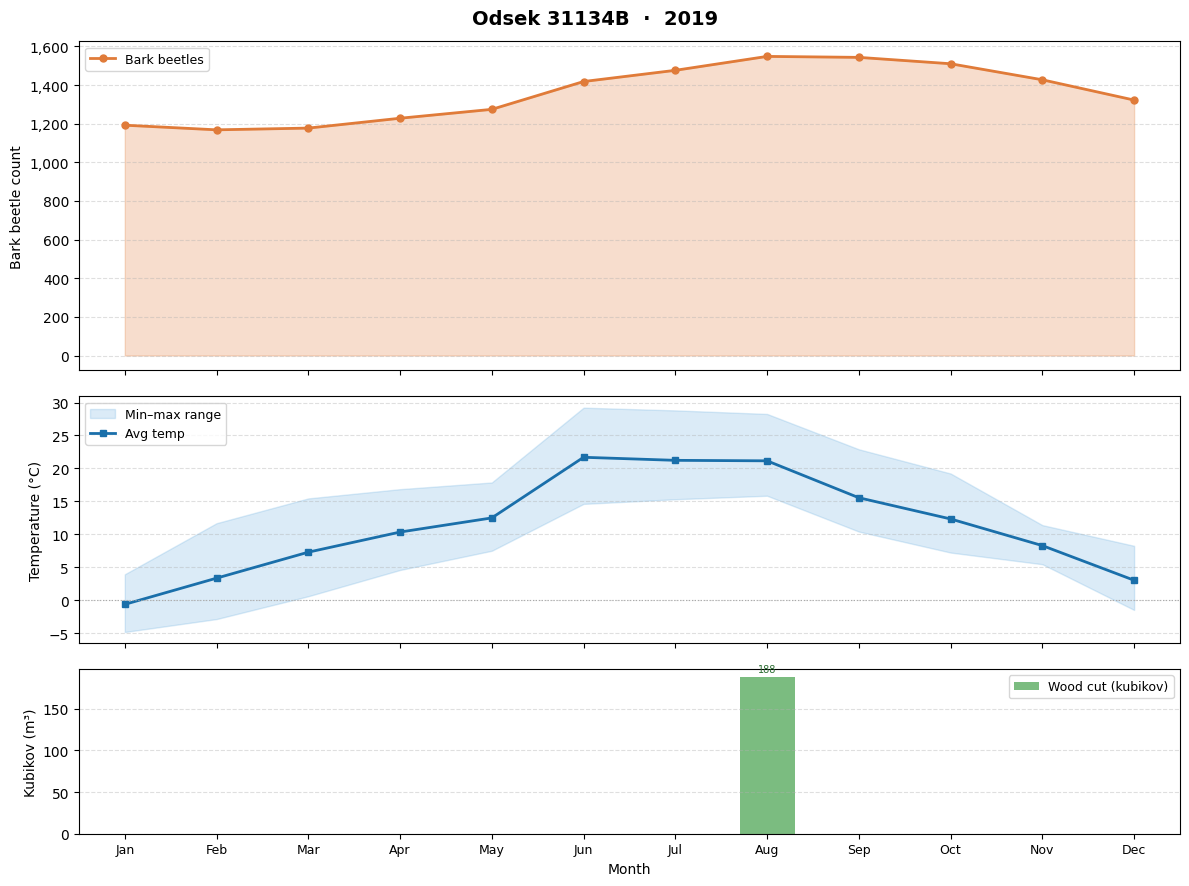

In [6]:
# ── 4. Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1.5, 1]},
)
fig.suptitle(
    f"Odsek {ODSEK_ID}  ·  {YEAR}",
    fontsize=14, fontweight="bold", y=0.98
)

x = np.arange(1, 13)

# ── panel 1: bark beetle count ─────────────────────────────────────────────
ax1 = axes[0]
beetle_vals = bb_year["bark_beetle_count"].values.astype(float)
ax1.fill_between(x, beetle_vals, alpha=0.25, color="#e07b39")
ax1.plot(x, beetle_vals, color="#e07b39", linewidth=2.0, marker="o", markersize=5, label="Bark beetles")
ax1.set_ylabel("Bark beetle count", fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend(loc="upper left", fontsize=9)
ax1.set_xlim(0.5, 12.5)

# ── panel 2: temperature ───────────────────────────────────────────────────
ax2 = axes[1]
avg_t = vreme_monthly["avg"].values.astype(float)
hi_t  = vreme_monthly["hi"].values.astype(float)
lo_t  = vreme_monthly["lo"].values.astype(float)

ax2.fill_between(x, lo_t, hi_t, alpha=0.20, color="#4c9ed9", label="Min–max range")
ax2.plot(x, avg_t, color="#1a6faa", linewidth=2.0, marker="s", markersize=5, label="Avg temp")
ax2.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle=":")
ax2.set_ylabel("Temperature (°C)", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(loc="upper left", fontsize=9)

# ── panel 3: wood cut (posek) ──────────────────────────────────────────────
ax3 = axes[2]
kub = posek_sel.values.astype(float)
bars = ax3.bar(x, kub, color="#5aab61", alpha=0.8, width=0.6, label="Wood cut (kubikov)")
ax3.set_ylabel("Kubikov (m³)", fontsize=10)
ax3.set_xlabel("Month", fontsize=10)
ax3.grid(axis="y", linestyle="--", alpha=0.4)
ax3.legend(loc="upper right", fontsize=9)

# shared x-axis ticks
ax3.set_xticks(x)
ax3.set_xticklabels(MONTH_ABBR, fontsize=9)

# annotate bar values (only non-zero)
for bar, val in zip(bars, kub):
    if val > 0:
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + kub.max() * 0.02,
            f"{val:.0f}",
            ha="center", va="bottom", fontsize=7, color="#2d6e33"
        )

plt.tight_layout()
plt.show()